# CRN Context Space Analysis

**Question:** Does the trained encoder produce context vectors with useful structure
for comparing CRNs that differ by small edits?

**Method:** Sample base CRNs, apply single-reaction edits of known types, encode all
CRNs, and analyze whether similar edits produce similar context vector changes
regardless of the base CRN.

**What success looks like:** Context vector differences (Δc = c_edited - c_base)
cluster by edit type in PCA space. This would mean the encoder has learned a
representation where "adding degradation for species 0" has a consistent direction
in context space, which is exactly the structure needed for the iterative CRN
design model.


In [1]:
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules
if COLAB:
    import os
    import subprocess

    _CLONE_DIR = "/content/CRN_Surrogate"
    if not os.path.exists(_CLONE_DIR):
        subprocess.check_call(
            [
                "git",
                "clone",
                "-q",
                "https://github.com/Mijan/CRN_Surrogate.git",
                _CLONE_DIR,
            ]
        )
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "-e", _CLONE_DIR]
        )
    sys.path.insert(0, _CLONE_DIR)
    os.chdir(_CLONE_DIR)
else:
    sys.path.insert(0, str(Path("../..").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## 1. Load Trained Model

Load the encoder from a W&B artifact or a local checkpoint. The SDE is not
needed for this analysis since we only use the encoder's context vectors.

In [2]:
from experiments.configs.mass_action_3s import (
    MassAction3sV7Config,
)

from crn_surrogate.encoder.bipartite_gnn import BipartiteGNNEncoder
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr

cfg = MassAction3sV7Config()
model_config = cfg.build_model_config()

# --- Option A: Load from W&B artifact ---
USE_WANDB = True  # Set True to load from W&B

ckpt = None
if USE_WANDB:
    import wandb

    api = wandb.Api()

    # Try 1: final model artifact (uploaded after training completes)
    # Try 2: intermediate training checkpoint (uploaded during training)
    artifact_candidates = [
        f"jan-mikelson-independent/crn-surrogate/{cfg.experiment_name}_model:latest",
        f"jan-mikelson-independent/crn-surrogate/{cfg.experiment_name}_train_periodic_checkpoint:latest",
    ]
    for artifact_ref in artifact_candidates:
        try:
            artifact = api.artifact(artifact_ref)
            artifact_dir = Path(artifact.download())
            ckpt_path = sorted(artifact_dir.glob("*.pt"))[-1]
            print(f"Loaded from W&B: {artifact_ref}")
            print(f"  File: {ckpt_path.name}")
            ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
            if "epoch" in ckpt:
                print(f"  Epoch: {ckpt['epoch']}")
            break
        except Exception as e:
            print(f"  Not found: {artifact_ref} ({e})")
else:
    # --- Option B: Load from local path ---
    ckpt_path = Path("../../notebooks/experiments/checkpoints/best_epoch15.pt")

print(f"Loading: {ckpt_path}")
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

encoder = BipartiteGNNEncoder(model_config.encoder)
encoder.load_state_dict(ckpt["encoder_state"])
encoder.eval()
print(f"Encoder loaded ({sum(p.numel() for p in encoder.parameters()):,} params)")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jan/.netrc.


  Not found: jan-mikelson-independent/crn-surrogate/mass_action_3s_v7_model:latest (artifact membership 'mass_action_3s_v7_model:latest' not found in 'jan-mikelson-independent/crn-surrogate')


wandb:   1 of 1 files downloaded.  


Loaded from W&B: jan-mikelson-independent/crn-surrogate/mass_action_3s_v7_train_periodic_checkpoint:latest
  File: periodic_epoch50.pt
  Epoch: 50
Loading: /home/jan/Dropbox/personal_projects/CRN_Surrogate/experiments/analysis/artifacts/mass_action_3s_v7_train_periodic_checkpoint:v16/periodic_epoch50.pt
Encoder loaded (273,472 params)


## 2. Define Single-Reaction Edit Types

Each edit type is a function that takes a MassActionTopology and returns a
modified topology with one additional reaction. The edit types cover the basic
mass-action reaction vocabulary.

In [3]:
from crn_surrogate.data.generation.mass_action_generator import (
    MassActionCRNGenerator,
    MassActionGeneratorConfig,
    RandomTopologyConfig,
)
from crn_surrogate.data.generation.mass_action_topology import MassActionTopology


def add_production(topo: MassActionTopology, species: int) -> MassActionTopology | None:
    """Add 0 -> S_i (constitutive production)."""
    n_s = topo.n_species
    new_r = torch.zeros(1, n_s)
    new_p = torch.zeros(1, n_s)
    new_p[0, species] = 1.0
    try:
        return MassActionTopology(
            reactant_matrix=torch.cat([topo.reactant_matrix, new_r]),
            product_matrix=torch.cat([topo.product_matrix, new_p]),
        )
    except ValueError:
        return None  # duplicate or other violation


def add_degradation(
    topo: MassActionTopology, species: int
) -> MassActionTopology | None:
    """Add S_i -> 0 (first-order degradation)."""
    n_s = topo.n_species
    new_r = torch.zeros(1, n_s)
    new_r[0, species] = 1.0
    new_p = torch.zeros(1, n_s)
    try:
        return MassActionTopology(
            reactant_matrix=torch.cat([topo.reactant_matrix, new_r]),
            product_matrix=torch.cat([topo.product_matrix, new_p]),
        )
    except ValueError:
        return None


def add_conversion(
    topo: MassActionTopology, source: int, target: int
) -> MassActionTopology | None:
    """Add S_i -> S_j (first-order conversion)."""
    if source == target:
        return None
    n_s = topo.n_species
    new_r = torch.zeros(1, n_s)
    new_r[0, source] = 1.0
    new_p = torch.zeros(1, n_s)
    new_p[0, target] = 1.0
    try:
        return MassActionTopology(
            reactant_matrix=torch.cat([topo.reactant_matrix, new_r]),
            product_matrix=torch.cat([topo.product_matrix, new_p]),
        )
    except ValueError:
        return None


def add_catalytic_production(
    topo: MassActionTopology, catalyst: int, product: int
) -> MassActionTopology | None:
    """Add S_i -> S_i + S_j (catalytic production, catalyst unchanged)."""
    if catalyst == product:
        return None
    n_s = topo.n_species
    new_r = torch.zeros(1, n_s)
    new_r[0, catalyst] = 1.0
    new_p = torch.zeros(1, n_s)
    new_p[0, catalyst] = 1.0
    new_p[0, product] = 1.0
    try:
        return MassActionTopology(
            reactant_matrix=torch.cat([topo.reactant_matrix, new_r]),
            product_matrix=torch.cat([topo.product_matrix, new_p]),
        )
    except ValueError:
        return None


def add_dimerization(
    topo: MassActionTopology, species: int, product: int
) -> MassActionTopology | None:
    """Add 2S_i -> S_j (dimerization)."""
    n_s = topo.n_species
    new_r = torch.zeros(1, n_s)
    new_r[0, species] = 2.0
    new_p = torch.zeros(1, n_s)
    new_p[0, product] = 1.0
    try:
        return MassActionTopology(
            reactant_matrix=torch.cat([topo.reactant_matrix, new_r]),
            product_matrix=torch.cat([topo.product_matrix, new_p]),
        )
    except ValueError:
        return None


def add_binding(
    topo: MassActionTopology, s1: int, s2: int, product: int
) -> MassActionTopology | None:
    """Add S_i + S_j -> S_k (bimolecular binding)."""
    if s1 == s2:
        return None
    n_s = topo.n_species
    new_r = torch.zeros(1, n_s)
    new_r[0, s1] = 1.0
    new_r[0, s2] = 1.0
    new_p = torch.zeros(1, n_s)
    new_p[0, product] = 1.0
    try:
        return MassActionTopology(
            reactant_matrix=torch.cat([topo.reactant_matrix, new_r]),
            product_matrix=torch.cat([topo.product_matrix, new_p]),
        )
    except ValueError:
        return None


EDIT_TYPES = {
    "production": add_production,
    "degradation": add_degradation,
    "conversion": add_conversion,
    "catalytic_prod": add_catalytic_production,
    "dimerization": add_dimerization,
    "binding": add_binding,
}

print(f"Defined {len(EDIT_TYPES)} edit types")

Defined 6 edit types


## 3. Generate Base CRNs and Apply Edits

For each base CRN, we apply every applicable edit type and record the
context vectors of both the base and edited CRN.

In [4]:
config = MassActionGeneratorConfig(
    topology=RandomTopologyConfig(
        n_species_range=(2, 3),  # need >=2 for conversion/binding edits
        n_reactions_range=(2, 4),  # keep base small so edits are meaningful
    ),
    rate_constant_range=(0.1, 5.0),
)
gen = MassActionCRNGenerator(config)

N_BASE = 40
RATE_FOR_NEW_REACTION = 1.0  # fixed rate for the added reaction

torch.manual_seed(42)
base_topos = gen._topology_sampler.sample_batch(N_BASE)

records = []  # list of dicts with edit metadata and context vectors

for base_idx, base_topo in enumerate(base_topos):
    n_s = base_topo.n_species
    # Assign fixed rates to the base
    base_rates = [1.0] * base_topo.n_reactions
    base_crn = base_topo.to_crn(base_rates)
    base_repr = crn_to_tensor_repr(base_crn)

    with torch.no_grad():
        base_ctx = encoder(base_repr).context_vector.numpy()

    # Try each edit type with various species arguments
    for edit_name, edit_fn in EDIT_TYPES.items():
        # Generate species argument combinations
        if edit_name in ("production", "degradation"):
            args_list = [{"species": s} for s in range(n_s)]
        elif edit_name == "conversion":
            args_list = [
                {"source": s, "target": t}
                for s in range(n_s)
                for t in range(n_s)
                if s != t
            ]
        elif edit_name == "catalytic_prod":
            args_list = [
                {"catalyst": s, "product": t}
                for s in range(n_s)
                for t in range(n_s)
                if s != t
            ]
        elif edit_name == "dimerization":
            args_list = [
                {"species": s, "product": t} for s in range(n_s) for t in range(n_s)
            ]
        elif edit_name == "binding":
            args_list = [
                {"s1": i, "s2": j, "product": k}
                for i in range(n_s)
                for j in range(i + 1, n_s)
                for k in range(n_s)
            ]
        else:
            args_list = []

        for kwargs in args_list:
            edited_topo = edit_fn(base_topo, **kwargs)
            if edited_topo is None:
                continue

            edited_rates = base_rates + [RATE_FOR_NEW_REACTION]
            edited_crn = edited_topo.to_crn(edited_rates)
            edited_repr = crn_to_tensor_repr(edited_crn)

            with torch.no_grad():
                edited_ctx = encoder(edited_repr).context_vector.numpy()

            delta_c = edited_ctx - base_ctx
            records.append(
                {
                    "base_idx": base_idx,
                    "edit_type": edit_name,
                    "species_args": str(kwargs),
                    "base_ctx": base_ctx,
                    "edited_ctx": edited_ctx,
                    "delta_c": delta_c,
                    "n_species": n_s,
                }
            )

print(f"Generated {len(records)} (base, edit) pairs")
edit_counts = {}
for r in records:
    edit_counts[r["edit_type"]] = edit_counts.get(r["edit_type"], 0) + 1
for k, v in sorted(edit_counts.items()):
    print(f"  {k}: {v}")

Generated 948 (base, edit) pairs
  binding: 242
  catalytic_prod: 168
  conversion: 161
  degradation: 40
  dimerization: 275
  production: 62


## 4. PCA on Context Vector Differences

If the encoder has learned useful structure, edits of the same type should
produce similar Δc vectors regardless of which base CRN they were applied to.
This would show as clusters in PCA space colored by edit type.

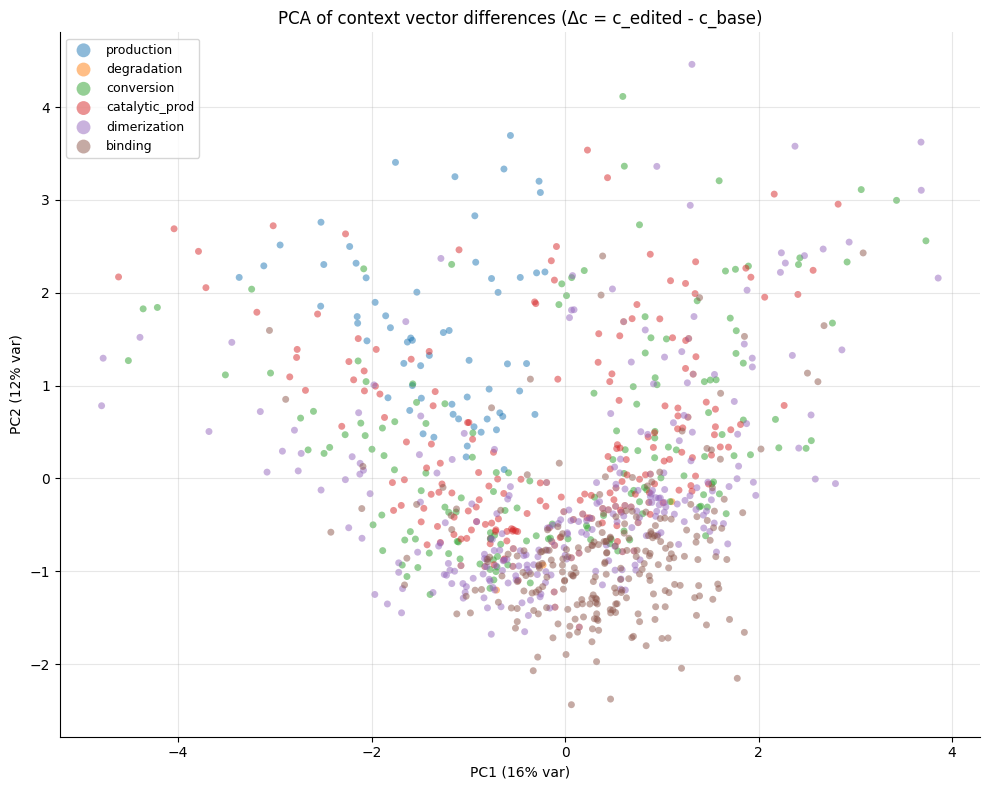

Variance explained: PC1=15.9%, PC2=12.3%, total=28.2%


In [5]:
delta_matrix = np.stack([r["delta_c"] for r in records])
edit_labels = [r["edit_type"] for r in records]

pca = PCA(n_components=2)
delta_2d = pca.fit_transform(delta_matrix)

COLORS = {
    "production": "#1f77b4",
    "degradation": "#ff7f0e",
    "conversion": "#2ca02c",
    "catalytic_prod": "#d62728",
    "dimerization": "#9467bd",
    "binding": "#8c564b",
}

fig, ax = plt.subplots(figsize=(10, 8))
for edit_type, color in COLORS.items():
    mask = [l == edit_type for l in edit_labels]
    if not any(mask):
        continue
    pts = delta_2d[mask]
    ax.scatter(
        pts[:, 0],
        pts[:, 1],
        c=color,
        label=edit_type,
        alpha=0.5,
        s=25,
        edgecolors="none",
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
ax.set_title("PCA of context vector differences (Δc = c_edited - c_base)")
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

print(
    f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, "
    f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
    f"total={pca.explained_variance_ratio_[:2].sum():.1%}"
)

### t-SNE visualization

t-SNE preserves local structure better than PCA and may reveal clusters
that PCA misses.

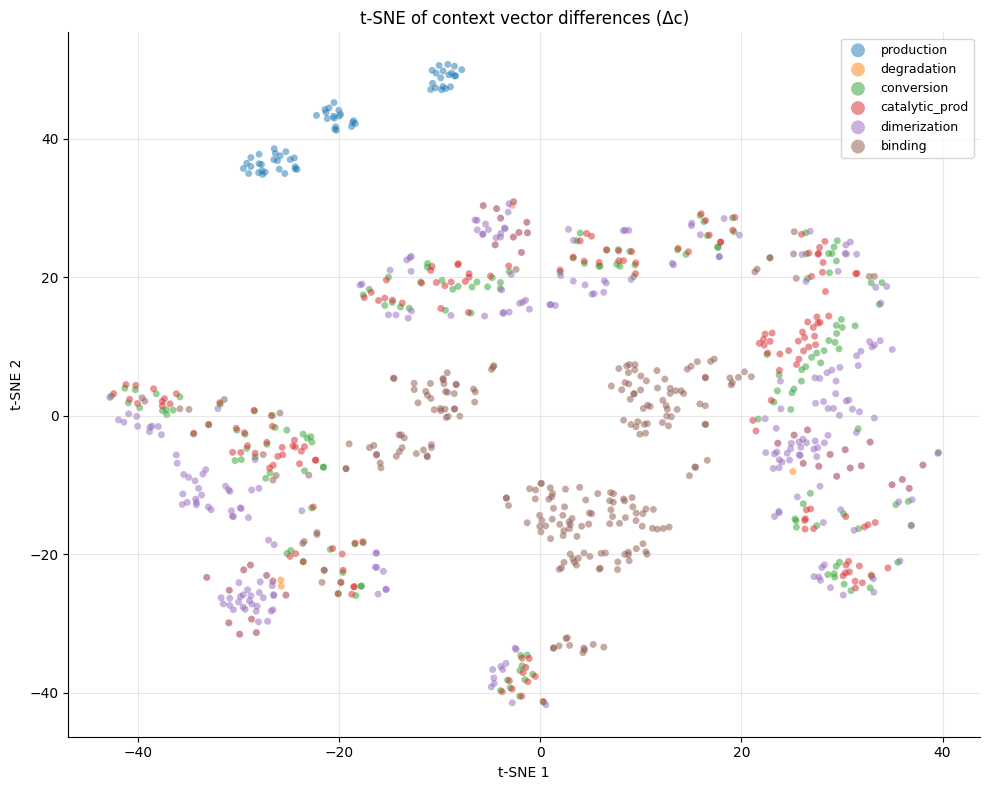

In [6]:
tsne = TSNE(n_components=2, perplexity=min(30, len(records) // 4), random_state=42)
delta_tsne = tsne.fit_transform(delta_matrix)

fig, ax = plt.subplots(figsize=(10, 8))
for edit_type, color in COLORS.items():
    mask = [l == edit_type for l in edit_labels]
    if not any(mask):
        continue
    pts = delta_tsne[mask]
    ax.scatter(
        pts[:, 0],
        pts[:, 1],
        c=color,
        label=edit_type,
        alpha=0.5,
        s=25,
        edgecolors="none",
    )

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE of context vector differences (Δc)")
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

## 5. Quantitative Analysis: Within-Type vs Between-Type Similarity

If the context space has useful structure, Δc vectors from the same edit type
should be more similar to each other (higher cosine similarity) than to Δc
vectors from different edit types.

In [7]:
from itertools import combinations

# Normalize delta vectors
norms = np.linalg.norm(delta_matrix, axis=1, keepdims=True)
norms = np.clip(norms, 1e-8, None)
delta_normed = delta_matrix / norms

unique_types = sorted(set(edit_labels))

within_sims = {}
for et in unique_types:
    mask = [l == et for l in edit_labels]
    vecs = delta_normed[mask]
    if len(vecs) < 2:
        continue
    # Pairwise cosine similarities
    sim_matrix = vecs @ vecs.T
    # Upper triangle (exclude diagonal)
    triu_idx = np.triu_indices(len(vecs), k=1)
    within_sims[et] = sim_matrix[triu_idx].mean()

between_sims = {}
for et1, et2 in combinations(unique_types, 2):
    mask1 = [l == et1 for l in edit_labels]
    mask2 = [l == et2 for l in edit_labels]
    vecs1 = delta_normed[mask1]
    vecs2 = delta_normed[mask2]
    if len(vecs1) == 0 or len(vecs2) == 0:
        continue
    sim = (vecs1 @ vecs2.T).mean()
    between_sims[(et1, et2)] = sim

print("Within-type mean cosine similarity (higher = more consistent):")
for et, sim in sorted(within_sims.items(), key=lambda x: -x[1]):
    print(f"  {et:<20s}: {sim:.3f}")

mean_within = np.mean(list(within_sims.values()))
mean_between = np.mean(list(between_sims.values()))
print(f"\nMean within-type:  {mean_within:.3f}")
print(f"Mean between-type: {mean_between:.3f}")
print(f"Ratio:             {mean_within / max(mean_between, 1e-8):.2f}x")

if mean_within > mean_between * 1.5:
    print("\n>>> Context space shows meaningful edit-type structure.")
elif mean_within > mean_between:
    print("\n>>> Weak structure. May benefit from contrastive fine-tuning.")
else:
    print(
        "\n>>> No structure. Edits of the same type are not more similar than different types."
    )

Within-type mean cosine similarity (higher = more consistent):
  production          : 0.526
  binding             : 0.239
  catalytic_prod      : 0.208
  degradation         : 0.152
  conversion          : 0.140
  dimerization        : 0.126

Mean within-type:  0.232
Mean between-type: 0.009
Ratio:             25.21x

>>> Context space shows meaningful edit-type structure.


## 6. Species-Specific Analysis

For production and degradation edits, does the context space distinguish
WHICH species is affected? If "add production of S0" has a different direction
than "add production of S1", the encoder captures species identity in its
edit representation.

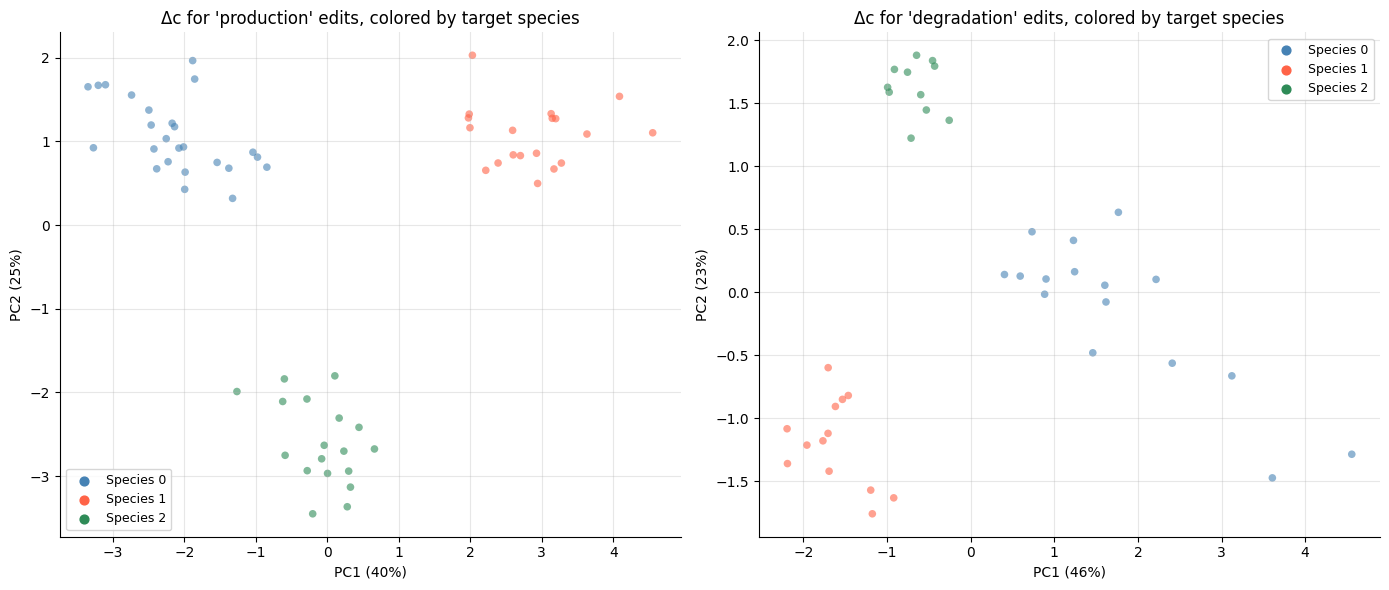

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, edit_type in zip(axes, ["production", "degradation"]):
    sub = [r for r in records if r["edit_type"] == edit_type]
    if len(sub) < 5:
        ax.text(0.5, 0.5, f"Too few {edit_type} edits", ha="center", va="center")
        continue

    sub_delta = np.stack([r["delta_c"] for r in sub])
    sub_args = [r["species_args"] for r in sub]

    pca_sub = PCA(n_components=2)
    sub_2d = pca_sub.fit_transform(sub_delta)

    # Color by species index (extracted from args string)
    species_colors = {"0": "steelblue", "1": "tomato", "2": "seagreen"}
    for i, r in enumerate(sub):
        # Extract species index from the args dict
        s_idx = str(list(eval(r["species_args"]).values())[0])
        c = species_colors.get(s_idx, "gray")
        ax.scatter(sub_2d[i, 0], sub_2d[i, 1], c=c, alpha=0.6, s=30, edgecolors="none")

    # Legend
    for s_idx, color in species_colors.items():
        ax.scatter([], [], c=color, label=f"Species {s_idx}", s=40)
    ax.legend(fontsize=9)
    ax.set_xlabel(f"PC1 ({pca_sub.explained_variance_ratio_[0]:.0%})")
    ax.set_ylabel(f"PC2 ({pca_sub.explained_variance_ratio_[1]:.0%})")
    ax.set_title(f"Δc for '{edit_type}' edits, colored by target species")

plt.tight_layout()
plt.show()

## 7. Absolute Context Vectors

For reference, visualize the context vectors themselves (not the differences).
CRNs that share structural features should cluster.

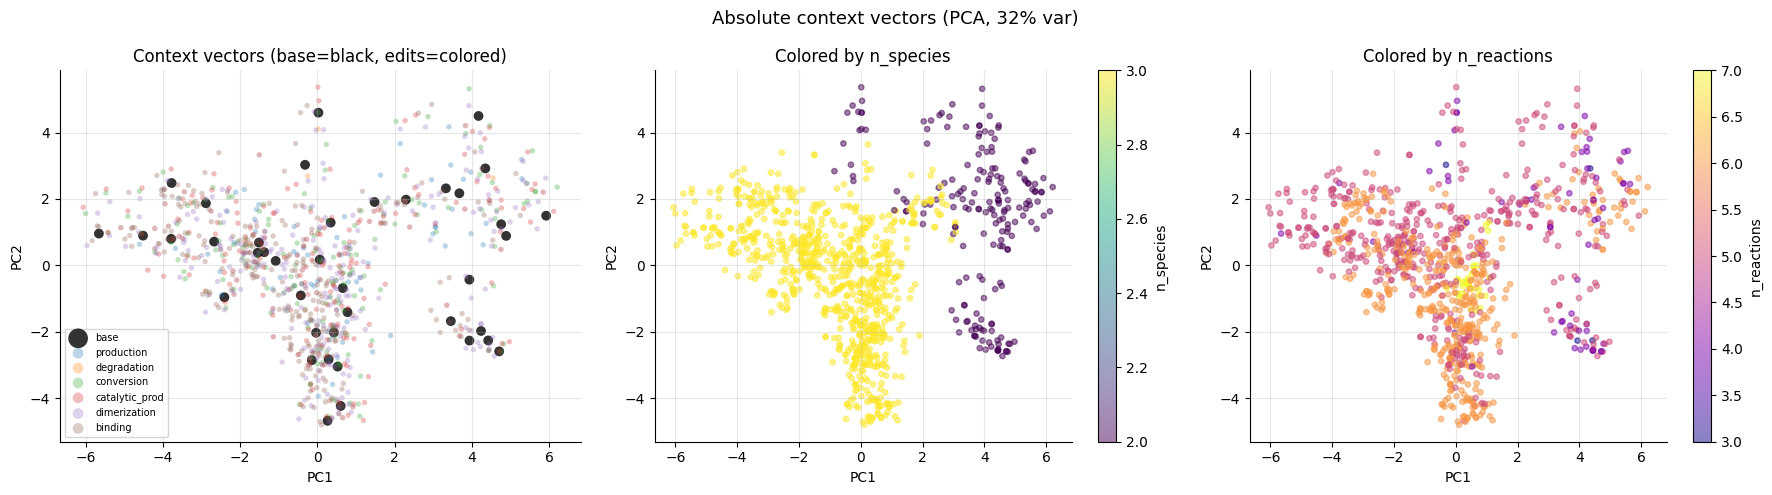

In [9]:
# Collect all unique context vectors (base + edited)
all_ctx = []
all_labels = []
all_n_species = []
all_n_reactions = []

seen_base = set()
for r in records:
    base_key = r["base_idx"]
    if base_key not in seen_base:
        seen_base.add(base_key)
        all_ctx.append(r["base_ctx"])
        all_labels.append("base")
        all_n_species.append(r["n_species"])
        all_n_reactions.append(base_topos[r["base_idx"]].n_reactions)

    all_ctx.append(r["edited_ctx"])
    all_labels.append(r["edit_type"])
    all_n_species.append(r["n_species"])
    all_n_reactions.append(base_topos[r["base_idx"]].n_reactions + 1)

ctx_matrix = np.stack(all_ctx)
pca_abs = PCA(n_components=2)
ctx_2d = pca_abs.fit_transform(ctx_matrix)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Colored by base vs edit type
COLORS_WITH_BASE = {"base": "black", **COLORS}
for label, color in COLORS_WITH_BASE.items():
    mask = [l == label for l in all_labels]
    if not any(mask):
        continue
    pts = ctx_2d[mask]
    alpha = 0.8 if label == "base" else 0.3
    size = 50 if label == "base" else 15
    ax = axes[0]
    ax.scatter(
        pts[:, 0],
        pts[:, 1],
        c=color,
        label=label,
        alpha=alpha,
        s=size,
        edgecolors="none",
    )
axes[0].legend(fontsize=7, markerscale=2)
axes[0].set_title("Context vectors (base=black, edits=colored)")
axes[0].set_xlabel(f"PC1 ({pca_abs.explained_variance_ratio_[0]:.0%})")

# Colored by n_species
sc1 = axes[1].scatter(
    ctx_2d[:, 0], ctx_2d[:, 1], c=all_n_species, cmap="viridis", s=15, alpha=0.5
)
axes[1].set_title("Colored by n_species")
plt.colorbar(sc1, ax=axes[1], label="n_species")

# Colored by n_reactions
sc2 = axes[2].scatter(
    ctx_2d[:, 0], ctx_2d[:, 1], c=all_n_reactions, cmap="plasma", s=15, alpha=0.5
)
axes[2].set_title("Colored by n_reactions")
plt.colorbar(sc2, ax=axes[2], label="n_reactions")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle(
    f"Absolute context vectors (PCA, {pca_abs.explained_variance_ratio_[:2].sum():.0%} var)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## 8. Edit Magnitude Analysis

How much does a single-reaction edit change the context vector? If production
edits produce larger Δc than degradation edits, the encoder weights them
differently.

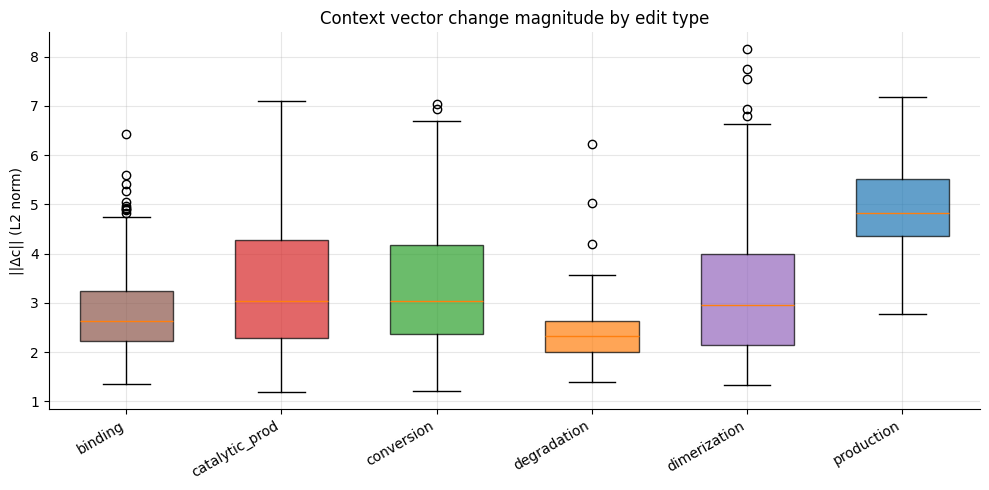

Mean ||Δc|| by edit type:
  binding             : 2.8493 +/- 0.9242
  catalytic_prod      : 3.3158 +/- 1.2377
  conversion          : 3.3397 +/- 1.2385
  degradation         : 2.5272 +/- 0.9296
  dimerization        : 3.1862 +/- 1.3080
  production          : 4.8752 +/- 0.9576


In [10]:
magnitudes = {}
for r in records:
    et = r["edit_type"]
    mag = np.linalg.norm(r["delta_c"])
    magnitudes.setdefault(et, []).append(mag)

fig, ax = plt.subplots(figsize=(10, 5))
types_sorted = sorted(magnitudes.keys())
positions = range(len(types_sorted))
bp = ax.boxplot(
    [magnitudes[t] for t in types_sorted],
    positions=list(positions),
    widths=0.6,
    patch_artist=True,
)
for patch, t in zip(bp["boxes"], types_sorted):
    patch.set_facecolor(COLORS.get(t, "gray"))
    patch.set_alpha(0.7)

ax.set_xticks(list(positions))
ax.set_xticklabels(types_sorted, rotation=30, ha="right")
ax.set_ylabel("||Δc|| (L2 norm)")
ax.set_title("Context vector change magnitude by edit type")
plt.tight_layout()
plt.show()

print("Mean ||Δc|| by edit type:")
for t in types_sorted:
    arr = np.array(magnitudes[t])
    print(f"  {t:<20s}: {arr.mean():.4f} +/- {arr.std():.4f}")

## 9. Summary and Implications

**What to look for in the results above:**

1. **Clustered Δc by edit type (Sections 4-5):** If yes, the context space has
   reaction-edit structure. The iterative CRN design model can learn to predict
   edit types as directions in this space.

2. **Species-resolved Δc (Section 6):** If production/degradation edits for
   different species are distinguishable, the encoder captures species identity
   in its representation of structural changes.

3. **Consistent magnitudes (Section 8):** If all edit types produce similar
   ||Δc||, the context space has uniform resolution across edit types. If some
   edits produce much larger changes, the encoder is more sensitive to those.

4. **Smooth absolute context space (Section 7):** If base CRNs and their edits
   form smooth clusters (not scattered randomly), the encoder has learned a
   continuous manifold of CRN structures.

**Next steps based on results:**

- If Δc clusters cleanly: proceed with the iterative edit model. The context
  space already provides the geometry needed for reaction-level predictions.
  
- If Δc shows weak structure: consider contrastive fine-tuning of the encoder
  (train with a loss that pulls same-edit-type Δc vectors together and pushes
  different-type vectors apart).
  
- If no structure at all: the encoder was trained for trajectory prediction,
  not structural comparison. A separate "edit encoder" may be needed, or the
  graph edit model should operate on the graph directly rather than in context
  space.
